FINAL MODEL VALIDATION

AI-Based Instagram Engagement Prediction and
Content Optimization System

Final validation of the Synthetic V2 champion model.


PROJECT STRUCTURE VALIDATION
Project root   : d:\newwwwwwww\AiBasedInstagramPrediction
Dataset path   : d:\newwwwwwww\AiBasedInstagramPrediction\datasets\Synthetic\synthetic_instagram_engagement_dataset_v2.csv
Dataset exists : True
Models folder  : d:\newwwwwwww\AiBasedInstagramPrediction\models
Results folder : d:\newwwwwwww\AiBasedInstagramPrediction\results

LOADING SYNTHETIC V2 DATASET

Rows    : 100000
Columns : 62

Target column: performance_class

Target distribution:


,Count,Percentage
performance_class,,
Medium,36000,36.0
High,32000,32.0
Low,32000,32.0



Missing target values: 0

FINAL LEAKAGE AUDIT

Identifier columns found:
  EXCLUDE: post_id
  EXCLUDE: account_id

Post-publication columns found:
  None

Raw high-cardinality fields found:
  EXCLUDE: caption
  EXCLUDE: hashtags
  EXCLUDE: posting_datetime

Total columns excluded from modelling:
5

Excluded columns:
  - post_id
  - account_id
  - caption
  - hashtags
  - posting_datetime

----------------------------------------------------------------------
POST-EXCLUSION LEAKAGE CHECK
----------------------------------------------------------------------
LEAKAGE CHECK: PASSED
No identifier or post-publication variables remain as predictors.

FINAL MODELLING DATASET
Original dataset columns : 62
Excluded columns        : 5
Final predictors        : 56
Records                 : 100000

EXPECTED 56-PREDICTOR STRUCTURE: PASSED

DATA TYPE NORMALISATION
Boolean/category normalization completed.

Numeric features     : 51
Categorical features : 5

Categorical features:
  category: 5 unique

,precision,recall,f1-score,support
High,0.9349,0.9228,0.9288,6400.0000
Low,0.9422,0.9152,0.9285,6400.0000
Medium,0.8611,0.8931,0.8768,7200.0000
accuracy,0.9096,0.9096,0.9096,0.9096
macro avg,0.9128,0.9103,0.9114,20000.0000
weighted avg,0.9107,0.9096,0.9100,20000.0000



CONFUSION MATRIX


,Predicted_High,Predicted_Low,Predicted_Medium
Actual_High,5906,0,494
Actual_Low,0,5857,543
Actual_Medium,411,359,6430


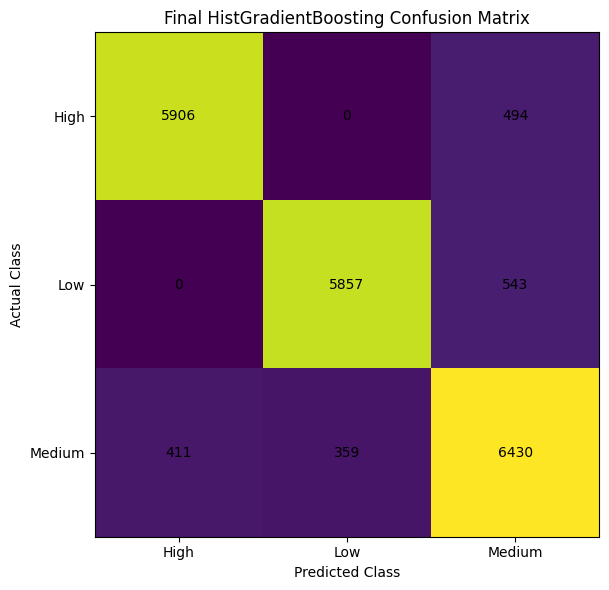


5-FOLD CROSS-VALIDATION CONFIRMATION

This is confirmation only.
No hyperparameter tuning is performed.

Fold-by-fold results:


,Fold,Training_Accuracy,Validation_Accuracy,Training_Weighted_F1,Validation_Weighted_F1,Fit_Time
0,1,0.9888,0.9055,0.9888,0.9058,15.5399
1,2,0.9888,0.9109,0.9889,0.9112,15.0411
2,3,0.9878,0.9078,0.9878,0.9081,13.1847
3,4,0.9892,0.9100,0.9892,0.9103,13.4712
4,5,0.9889,0.9062,0.9889,0.9066,13.9499



CROSS-VALIDATION SUMMARY

Mean Validation Accuracy : 90.8070%
Accuracy Std Deviation   : 0.2077%
Mean Validation F1       : 90.8403%
F1 Std Deviation         : 0.2065%
Mean Training Accuracy   : 98.8713%
Generalisation Gap       : 8.0643%
Total CV Time            : 87.74 seconds

90% TARGET VERIFICATION

🔥 90%+ HOLD-OUT ACCURACY ACHIEVED
🔥 90%+ CROSS-VALIDATED ACCURACY ACHIEVED

FINAL MODEL COMPARISON


,Model,Holdout_Accuracy,Weighted_F1,Selection_Status
0,HistGradientBoosting - Original,0.90965,0.909996,FINAL CHAMPION
1,HistGradientBoosting - Tuned,0.90925,0.909626,TUNED CANDIDATE
2,Extra Trees,0.83270,0.832597,PREVIOUS CANDIDATE
3,Random Forest,0.82200,0.822241,PREVIOUS CANDIDATE
4,Logistic Regression,0.53160,0.528828,PREVIOUS CANDIDATE



SAVING FINAL MODEL

Model saved successfully:
d:\newwwwwwww\AiBasedInstagramPrediction\models\final_instagram_engagement_model.joblib

Feature list saved:
d:\newwwwwwww\AiBasedInstagramPrediction\models\final_model_features.json

Model metadata saved:
d:\newwwwwwww\AiBasedInstagramPrediction\models\final_model_metadata.json

Model card saved:
d:\newwwwwwww\AiBasedInstagramPrediction\results\final_model_card.csv

SAVED MODEL RELOAD VERIFICATION

Reload prediction count: 100
Predictions match original: True

MODEL RELOAD CHECK: PASSED


FINAL MODEL VALIDATION COMPLETED

1. Dataset:
   Synthetic V2 - 100,000 records

2. Final model:
   HistGradientBoostingClassifier

3. Hold-out accuracy:
   90.9650%

4. Hold-out weighted F1:
   90.9996%

5. Mean 5-fold CV accuracy:
   90.8070%

6. Mean 5-fold CV weighted F1:
   90.8403%

7. Leakage check:
   PASSED

8. 90% hold-out target:
   ACHIEVED

9. 90% CV target:
   ACHIEVED

10. Final model:
    d:\newwwwwwww\AiBasedInstagramPrediction\models\fi

In [2]:
# ============================================================
# 13_FINAL_MODEL_VALIDATION.ipynb
# AI-BASED INSTAGRAM ENGAGEMENT PREDICTION SYSTEM
# ============================================================

import json
import time
import warnings
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# ============================================================
# 13.1 FINAL MODEL VALIDATION
# ============================================================

print("=" * 70)
print("FINAL MODEL VALIDATION")
print("=" * 70)

print("""
AI-Based Instagram Engagement Prediction and
Content Optimization System

Final validation of the Synthetic V2 champion model.
""")


# ============================================================
# 13.2 PROJECT PATH DETECTION
# ============================================================

print("\n" + "=" * 70)
print("PROJECT STRUCTURE VALIDATION")
print("=" * 70)

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT != PROJECT_ROOT.parent:

    if (
        (PROJECT_ROOT / "datasets").exists()
        and (PROJECT_ROOT / "models").exists()
    ):
        break

    PROJECT_ROOT = PROJECT_ROOT.parent


DATASET_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "Synthetic"
    / "synthetic_instagram_engagement_dataset_v2.csv"
)

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root   :", PROJECT_ROOT)
print("Dataset path   :", DATASET_PATH)
print("Dataset exists :", DATASET_PATH.exists())
print("Models folder  :", MODELS_DIR)
print("Results folder :", RESULTS_DIR)

if not DATASET_PATH.exists():

    raise FileNotFoundError(
        f"\nDataset not found:\n{DATASET_PATH}"
    )


# ============================================================
# 13.3 LOAD SYNTHETIC V2 DATASET
# ============================================================

print("\n" + "=" * 70)
print("LOADING SYNTHETIC V2 DATASET")
print("=" * 70)

df = pd.read_csv(DATASET_PATH)

print("\nRows    :", len(df))
print("Columns :", len(df.columns))

TARGET = "performance_class"

if TARGET not in df.columns:

    raise ValueError(
        f"Target column '{TARGET}' not found."
    )

print("\nTarget column:", TARGET)

print("\nTarget distribution:")
target_distribution = (
    df[TARGET]
    .value_counts()
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(df)
    * 100
)

display(
    target_distribution.round(2)
)

print(
    "\nMissing target values:",
    df[TARGET].isna().sum()
)


# ============================================================
# 13.4 FINAL LEAKAGE AUDIT
# ============================================================

print("\n" + "=" * 70)
print("FINAL LEAKAGE AUDIT")
print("=" * 70)


# ------------------------------------------------------------
# Identifiers
# ------------------------------------------------------------

IDENTIFIER_COLUMNS = [
    "post_id",
    "account_id"
]


# ------------------------------------------------------------
# Post-publication outcome variables
# ------------------------------------------------------------

POST_PUBLICATION_COLUMNS = [
    "likes",
    "comments",
    "shares",
    "saves",
    "reach",
    "impressions",
    "engagement_rate",
    "binary_performance"
]


# ------------------------------------------------------------
# Raw high-cardinality fields
#
# These were not used in the validated 90%+ baseline.
# ------------------------------------------------------------

RAW_HIGH_CARDINALITY_COLUMNS = [
    "caption",
    "hashtags",
    "posting_datetime"
]


# ------------------------------------------------------------
# Show what exists
# ------------------------------------------------------------

found_identifiers = [
    col
    for col in IDENTIFIER_COLUMNS
    if col in df.columns
]

found_post_publication = [
    col
    for col in POST_PUBLICATION_COLUMNS
    if col in df.columns
]

found_raw_high_cardinality = [
    col
    for col in RAW_HIGH_CARDINALITY_COLUMNS
    if col in df.columns
]


print("\nIdentifier columns found:")

if found_identifiers:

    for col in found_identifiers:
        print("  EXCLUDE:", col)

else:

    print("  None")


print("\nPost-publication columns found:")

if found_post_publication:

    for col in found_post_publication:
        print("  EXCLUDE:", col)

else:

    print("  None")


print("\nRaw high-cardinality fields found:")

if found_raw_high_cardinality:

    for col in found_raw_high_cardinality:
        print("  EXCLUDE:", col)

else:

    print("  None")


# ============================================================
# 13.5 CREATE FINAL MODELLING DATA
# ============================================================

# Everything below is excluded ONLY from modelling.
# The original CSV remains untouched.

EXCLUDED_COLUMNS = (
    found_identifiers
    + found_post_publication
    + found_raw_high_cardinality
)

print("\nTotal columns excluded from modelling:")
print(len(EXCLUDED_COLUMNS))

print("\nExcluded columns:")

for col in EXCLUDED_COLUMNS:

    print("  -", col)


# Create X and y

X = df.drop(
    columns=EXCLUDED_COLUMNS + [TARGET],
    errors="ignore"
).copy()

y = df[TARGET].astype(str).copy()


# ============================================================
# 13.6 POST-EXCLUSION LEAKAGE CHECK
# ============================================================

remaining_prohibited = [
    col
    for col in X.columns
    if col in (
        IDENTIFIER_COLUMNS
        + POST_PUBLICATION_COLUMNS
    )
]

print("\n" + "-" * 70)
print("POST-EXCLUSION LEAKAGE CHECK")
print("-" * 70)

if remaining_prohibited:

    print("LEAKAGE CHECK: FAILED")

    print(
        "Remaining prohibited columns:",
        remaining_prohibited
    )

    raise ValueError(
        "Prohibited columns remain after exclusion."
    )

else:

    print("LEAKAGE CHECK: PASSED")

    print(
        "No identifier or post-publication "
        "variables remain as predictors."
    )


# ============================================================
# 13.7 DATASET DIMENSION VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODELLING DATASET")
print("=" * 70)

print("Original dataset columns :", len(df.columns))
print("Excluded columns        :", len(EXCLUDED_COLUMNS))
print("Final predictors        :", len(X.columns))
print("Records                 :", len(X))


# Expected from the validated baseline:
# 56 predictors

if len(X.columns) == 56:

    print(
        "\nEXPECTED 56-PREDICTOR STRUCTURE: PASSED"
    )

else:

    print(
        f"\nWARNING: Expected 56 predictors, "
        f"found {len(X.columns)}."
    )


# ============================================================
# 13.8 DATA TYPE NORMALISATION
# ============================================================

print("\n" + "=" * 70)
print("DATA TYPE NORMALISATION")
print("=" * 70)


# Boolean → integer

for col in X.columns:

    if X[col].dtype == bool:

        X[col] = X[col].astype(int)


# Category → string

for col in X.columns:

    if str(X[col].dtype) == "category":

        X[col] = X[col].astype(str)


print("Boolean/category normalization completed.")


# ============================================================
# 13.9 IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_features = (
    X.select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        include=[
            "object",
            "category",
            "string"
        ]
    )
    .columns
    .tolist()
)


print("\nNumeric features     :", len(numeric_features))
print("Categorical features :", len(categorical_features))

print("\nCategorical features:")

for col in categorical_features:

    print(
        f"  {col}: "
        f"{X[col].nunique(dropna=False)} unique"
    )


# Expected validated structure:
# 51 numeric
# 5 categorical

if (
    len(numeric_features) == 51
    and len(categorical_features) == 5
):

    print(
        "\nEXPECTED 51 NUMERIC + 5 CATEGORICAL: PASSED"
    )

else:

    print(
        "\nWARNING: Feature-type structure differs "
        "from the previous baseline."
    )


# ============================================================
# 13.10 NUMERIC DATA CLEANING
# ============================================================

for col in numeric_features:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


# ============================================================
# 13.11 CATEGORICAL DATA CLEANING
# ============================================================

for col in categorical_features:

    X[col] = X[col].astype("string")


# ============================================================
# 13.12 TRAIN / TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("REPRODUCIBLE TRAIN / TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining records :", len(X_train))
print("Testing records  :", len(X_test))

print("\nTraining target distribution:")
print(
    y_train.value_counts(
        normalize=True
    ).round(4)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(
        normalize=True
    ).round(4)
)


# ============================================================
# 13.13 PREPROCESSING PIPELINE
# ============================================================

print("\n" + "=" * 70)
print("PREPROCESSING PIPELINE")
print("=" * 70)


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


print("Numeric strategy      : median imputation")
print("Categorical strategy  : most-frequent imputation")
print("Categorical encoding  : OneHotEncoder")
print("Unknown handling      : ignore")


# ============================================================
# 13.14 FINAL CHAMPION MODEL
# ============================================================

print("\n" + "=" * 70)
print("FINAL CHAMPION MODEL")
print("=" * 70)


MODEL_PARAMETERS = {
    "learning_rate": 0.08,
    "max_iter": 300,
    "max_leaf_nodes": 63,
    "min_samples_leaf": 20,
    "l2_regularization": 0.1,
    "random_state": 42
}


print(
    "\nModel:"
)

print(
    "HistGradientBoostingClassifier"
)


print("\nParameters:")

for key, value in MODEL_PARAMETERS.items():

    print(
        f"  {key}: {value}"
    )


classifier = HistGradientBoostingClassifier(
    **MODEL_PARAMETERS
)


final_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        classifier
    )
])


# ============================================================
# 13.15 FINAL MODEL TRAINING
# ============================================================

print("\n" + "=" * 70)
print("TRAINING FINAL CHAMPION MODEL")
print("=" * 70)

training_start = time.time()

final_pipeline.fit(
    X_train,
    y_train
)

training_time = (
    time.time()
    - training_start
)

print(
    f"\nTraining completed in "
    f"{training_time:.2f} seconds."
)


# ============================================================
# 13.16 FINAL HOLD-OUT PREDICTION
# ============================================================

print("\n" + "=" * 70)
print("FINAL HOLD-OUT TEST")
print("=" * 70)

predictions = final_pipeline.predict(
    X_test
)


# Probability support

try:

    probabilities = (
        final_pipeline
        .predict_proba(X_test)
    )

    probability_available = True

except Exception:

    probabilities = None

    probability_available = False


# ============================================================
# 13.17 FINAL PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions
)

weighted_precision = precision_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    f"\nAccuracy           : {accuracy:.4%}"
)

print(
    f"Weighted Precision : {weighted_precision:.4%}"
)

print(
    f"Weighted Recall    : {weighted_recall:.4%}"
)

print(
    f"Weighted F1        : {weighted_f1:.4%}"
)

print(
    f"Macro F1           : {macro_f1:.4%}"
)


# ============================================================
# 13.18 CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

classification_report_text = classification_report(
    y_test,
    predictions,
    zero_division=0
)

print(
    classification_report_text
)


classification_report_dict = classification_report(
    y_test,
    predictions,
    output_dict=True,
    zero_division=0
)

classification_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
)

display(
    classification_df.round(4)
)


classification_report_path = (
    RESULTS_DIR
    / "final_model_classification_report.csv"
)

classification_df.to_csv(
    classification_report_path
)


# ============================================================
# 13.19 CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

classes = sorted(
    y.unique()
)

cm = confusion_matrix(
    y_test,
    predictions,
    labels=classes
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"Actual_{c}"
        for c in classes
    ],
    columns=[
        f"Predicted_{c}"
        for c in classes
    ]
)

display(cm_df)

cm_path = (
    RESULTS_DIR
    / "final_model_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_path
)


# ============================================================
# 13.20 CONFUSION MATRIX VISUALISATION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.imshow(cm)

plt.title(
    "Final HistGradientBoosting Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

for i in range(len(classes)):

    for j in range(len(classes)):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_image_path = (
    RESULTS_DIR
    / "final_model_confusion_matrix.png"
)

plt.savefig(
    cm_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13.21 5-FOLD CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION CONFIRMATION")
print("=" * 70)

print(
    "\nThis is confirmation only."
)

print(
    "No hyperparameter tuning is performed."
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


cv_start = time.time()

cv_results = cross_validate(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "weighted_f1": "f1_weighted"
    },
    return_train_score=True,
    n_jobs=1
)

cv_time = (
    time.time()
    - cv_start
)


# ============================================================
# 13.22 FOLD-BY-FOLD RESULTS
# ============================================================

cv_df = pd.DataFrame({

    "Fold": [
        1,
        2,
        3,
        4,
        5
    ],

    "Training_Accuracy":
        cv_results[
            "train_accuracy"
        ],

    "Validation_Accuracy":
        cv_results[
            "test_accuracy"
        ],

    "Training_Weighted_F1":
        cv_results[
            "train_weighted_f1"
        ],

    "Validation_Weighted_F1":
        cv_results[
            "test_weighted_f1"
        ],

    "Fit_Time":
        cv_results[
            "fit_time"
        ]
})


print("\nFold-by-fold results:")

display(
    cv_df.round(4)
)


# ============================================================
# 13.23 CROSS-VALIDATION SUMMARY
# ============================================================

cv_mean_accuracy = (
    cv_results[
        "test_accuracy"
    ].mean()
)

cv_std_accuracy = (
    cv_results[
        "test_accuracy"
    ].std()
)

cv_mean_f1 = (
    cv_results[
        "test_weighted_f1"
    ].mean()
)

cv_std_f1 = (
    cv_results[
        "test_weighted_f1"
    ].std()
)

cv_mean_train_accuracy = (
    cv_results[
        "train_accuracy"
    ].mean()
)

generalisation_gap = (
    cv_mean_train_accuracy
    - cv_mean_accuracy
)


print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

print(
    f"\nMean Validation Accuracy : "
    f"{cv_mean_accuracy:.4%}"
)

print(
    f"Accuracy Std Deviation   : "
    f"{cv_std_accuracy:.4%}"
)

print(
    f"Mean Validation F1       : "
    f"{cv_mean_f1:.4%}"
)

print(
    f"F1 Std Deviation         : "
    f"{cv_std_f1:.4%}"
)

print(
    f"Mean Training Accuracy   : "
    f"{cv_mean_train_accuracy:.4%}"
)

print(
    f"Generalisation Gap       : "
    f"{generalisation_gap:.4%}"
)

print(
    f"Total CV Time            : "
    f"{cv_time:.2f} seconds"
)


cv_results_path = (
    RESULTS_DIR
    / "final_model_cross_validation.csv"
)

cv_df.to_csv(
    cv_results_path,
    index=False
)


# ============================================================
# 13.24 90% TARGET VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("90% TARGET VERIFICATION")
print("=" * 70)


if accuracy >= 0.90:

    holdout_target_status = "ACHIEVED"

    print(
        "\n🔥 90%+ HOLD-OUT ACCURACY ACHIEVED"
    )

else:

    holdout_target_status = "NOT ACHIEVED"

    print(
        "\n90%+ HOLD-OUT ACCURACY NOT ACHIEVED"
    )


if cv_mean_accuracy >= 0.90:

    cv_target_status = "ACHIEVED"

    print(
        "🔥 90%+ CROSS-VALIDATED ACCURACY ACHIEVED"
    )

else:

    cv_target_status = "NOT ACHIEVED"

    print(
        "90%+ CROSS-VALIDATED ACCURACY NOT ACHIEVED"
    )


# ============================================================
# 13.25 MODEL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)


comparison_df = pd.DataFrame({

    "Model": [

        "HistGradientBoosting - Original",
        "HistGradientBoosting - Tuned",
        "Extra Trees",
        "Random Forest",
        "Logistic Regression"
    ],

    "Holdout_Accuracy": [

        0.909650,
        0.909250,
        0.832700,
        0.822000,
        0.531600
    ],

    "Weighted_F1": [

        0.909996,
        0.909626,
        0.832597,
        0.822241,
        0.528828
    ],

    "Selection_Status": [

        "FINAL CHAMPION",
        "TUNED CANDIDATE",
        "PREVIOUS CANDIDATE",
        "PREVIOUS CANDIDATE",
        "PREVIOUS CANDIDATE"
    ]
})


display(
    comparison_df
)


comparison_path = (
    RESULTS_DIR
    / "final_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 13.26 FINAL MODEL SERIALIZATION
# ============================================================

print("\n" + "=" * 70)
print("SAVING FINAL MODEL")
print("=" * 70)


MODEL_PATH = (
    MODELS_DIR
    / "final_instagram_engagement_model.joblib"
)


joblib.dump(
    final_pipeline,
    MODEL_PATH
)


print(
    "\nModel saved successfully:"
)

print(
    MODEL_PATH
)


# ============================================================
# 13.27 SAVE FEATURE LIST
# ============================================================

feature_metadata = {

    "numeric_features":
        numeric_features,

    "categorical_features":
        categorical_features,

    "all_features":
        X.columns.tolist(),

    "excluded_columns":
        EXCLUDED_COLUMNS
}


FEATURE_PATH = (
    MODELS_DIR
    / "final_model_features.json"
)


with open(
    FEATURE_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        feature_metadata,
        file,
        indent=4
    )


print(
    "\nFeature list saved:"
)

print(
    FEATURE_PATH
)


# ============================================================
# 13.28 SAVE MODEL METADATA
# ============================================================

metadata = {

    "project_name":
        "AI-Based Instagram Engagement Prediction and Content Optimization System",

    "dataset_name":
        "Synthetic V2",

    "dataset_path":
        str(DATASET_PATH),

    "dataset_rows":
        int(len(df)),

    "dataset_columns":
        int(len(df.columns)),

    "target_column":
        TARGET,

    "target_classes":
        sorted(
            y.unique().tolist()
        ),

    "model_name":
        "HistGradientBoostingClassifier",

    "model_parameters":
        MODEL_PARAMETERS,

    "training_rows":
        int(len(X_train)),

    "testing_rows":
        int(len(X_test)),

    "feature_count":
        int(X.shape[1]),

    "numeric_feature_count":
        int(len(numeric_features)),

    "categorical_feature_count":
        int(len(categorical_features)),

    "holdout_accuracy":
        float(accuracy),

    "weighted_precision":
        float(weighted_precision),

    "weighted_recall":
        float(weighted_recall),

    "weighted_f1":
        float(weighted_f1),

    "macro_f1":
        float(macro_f1),

    "cv_mean_accuracy":
        float(cv_mean_accuracy),

    "cv_std_accuracy":
        float(cv_std_accuracy),

    "cv_mean_weighted_f1":
        float(cv_mean_f1),

    "cv_std_weighted_f1":
        float(cv_std_f1),

    "generalisation_gap":
        float(generalisation_gap),

    "training_time_seconds":
        float(training_time),

    "random_state":
        42,

    "excluded_identifier_columns":
        found_identifiers,

    "excluded_post_publication_columns":
        found_post_publication,

    "excluded_raw_high_cardinality_columns":
        found_raw_high_cardinality,

    "leakage_status":
        "PASSED",

    "ninety_percent_holdout_target":
        holdout_target_status,

    "ninety_percent_cv_target":
        cv_target_status,

    "validation_date":
        datetime.now().isoformat()
}


METADATA_PATH = (
    MODELS_DIR
    / "final_model_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )


print(
    "\nModel metadata saved:"
)

print(
    METADATA_PATH
)


# ============================================================
# 13.29 FINAL MODEL CARD
# ============================================================

model_card = pd.DataFrame({

    "Metric": [

        "Dataset",
        "Dataset Rows",
        "Dataset Columns",
        "Target",
        "Model",
        "Hold-out Accuracy",
        "Hold-out Weighted F1",
        "Hold-out Macro F1",
        "Mean CV Accuracy",
        "CV Accuracy Std",
        "Mean CV Weighted F1",
        "CV F1 Std",
        "Training Records",
        "Testing Records",
        "Feature Count",
        "Numeric Feature Count",
        "Categorical Feature Count",
        "Leakage Status",
        "90% Hold-out Target",
        "90% CV Target"
    ],

    "Value": [

        "Synthetic V2",
        len(df),
        len(df.columns),
        TARGET,
        "HistGradientBoostingClassifier",
        accuracy,
        weighted_f1,
        macro_f1,
        cv_mean_accuracy,
        cv_std_accuracy,
        cv_mean_f1,
        cv_std_f1,
        len(X_train),
        len(X_test),
        X.shape[1],
        len(numeric_features),
        len(categorical_features),
        "PASSED",
        holdout_target_status,
        cv_target_status
    ]
})


MODEL_CARD_PATH = (
    RESULTS_DIR
    / "final_model_card.csv"
)


model_card.to_csv(
    MODEL_CARD_PATH,
    index=False
)


print(
    "\nModel card saved:"
)

print(
    MODEL_CARD_PATH
)


# ============================================================
# 13.30 SAVED MODEL RELOAD TEST
# ============================================================

print("\n" + "=" * 70)
print("SAVED MODEL RELOAD VERIFICATION")
print("=" * 70)


loaded_model = joblib.load(
    MODEL_PATH
)


reload_predictions = (
    loaded_model
    .predict(
        X_test.iloc[:100]
    )
)


original_predictions = (
    predictions[:100]
)


reload_match = np.array_equal(
    reload_predictions,
    original_predictions
)


print(
    "\nReload prediction count:",
    len(reload_predictions)
)

print(
    "Predictions match original:",
    reload_match
)


if not reload_match:

    raise ValueError(
        "Saved model reload verification failed."
    )


print(
    "\nMODEL RELOAD CHECK: PASSED"
)


# ============================================================
# 13.31 FINAL COMPLETION REPORT
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MODEL VALIDATION COMPLETED")
print("=" * 70)

print(
    "\n1. Dataset:"
)

print(
    "   Synthetic V2 - 100,000 records"
)

print(
    "\n2. Final model:"
)

print(
    "   HistGradientBoostingClassifier"
)

print(
    "\n3. Hold-out accuracy:"
)

print(
    f"   {accuracy:.4%}"
)

print(
    "\n4. Hold-out weighted F1:"
)

print(
    f"   {weighted_f1:.4%}"
)

print(
    "\n5. Mean 5-fold CV accuracy:"
)

print(
    f"   {cv_mean_accuracy:.4%}"
)

print(
    "\n6. Mean 5-fold CV weighted F1:"
)

print(
    f"   {cv_mean_f1:.4%}"
)

print(
    "\n7. Leakage check:"
)

print(
    "   PASSED"
)

print(
    "\n8. 90% hold-out target:"
)

print(
    f"   {holdout_target_status}"
)

print(
    "\n9. 90% CV target:"
)

print(
    f"   {cv_target_status}"
)

print(
    "\n10. Final model:"
)

print(
    f"    {MODEL_PATH}"
)

print(
    "\n11. Model metadata:"
)

print(
    f"    {METADATA_PATH}"
)

print(
    "\n12. Feature list:"
)

print(
    f"    {FEATURE_PATH}"
)

print(
    "\n13. Classification report:"
)

print(
    f"    {classification_report_path}"
)

print(
    "\n14. Confusion matrix:"
)

print(
    f"    {cm_path}"
)

print(
    "\n15. Cross-validation results:"
)

print(
    f"    {cv_results_path}"
)

print(
    "\n16. Model comparison:"
)

print(
    f"    {comparison_path}"
)

print(
    "\n17. Model card:"
)

print(
    f"    {MODEL_CARD_PATH}"
)

print("\n" + "=" * 70)

print(
    "FINAL CHAMPION: HISTGRADIENTBOOSTING"
)

print(
    "READY FOR IMAGE INTEGRATION"
)

print("=" * 70)